In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from drone_dataset import get_dataloaders

                                        
                                                                         
                                                                        
                                                                                
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

               
                                                                                
                                                                              
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristimo uređaj: {device}")

                                                                                 
train_loader, val_loader, test_loader = get_dataloaders(batch_size=64)

print(f"Broj batch-eva u train_loader: {len(train_loader)}")
print(f"Broj batch-eva u val_loader: {len(val_loader)}")

Koristimo uređaj: cuda
Broj batch-eva u train_loader: 1080
Broj batch-eva u val_loader: 232


In [3]:
class BaselineCNN(nn.Module):
    """
    Jednostavna CNN arhitektura za klasifikaciju spektrograma.
    Ulaz: [batch_size, 2, 128, 128] (2 kanala, 128x128 "slika")
    Izlaz: [batch_size, 7] (verovatnoća za svaku od 7 klasa)
    """

    def __init__(self, num_classes=7):
        super().__init__()                                                              

                                                                             
                                                                                  
                                                                                
                                                        
        self.conv1 = nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, padding=1)                                  
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)                                                                                                              
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

                                                                                  
                                                                                     
        self.relu = nn.ReLU()

                                                                                      
                                                                                  
                                            
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

                                                                    
                                                                                     
                                                                                   
        self.flatten = nn.Flatten()                                                           
        self.fc1 = nn.Linear(64 * 16 * 16, 128)                                                                                                                                                                                                                                                  
        self.dropout = nn.Dropout(0.3)                                                                    
        self.fc2 = nn.Linear(128, num_classes)                                                                                                                                                                                                                                                        

    def forward(self, x):
        """
        Definiše kako podaci PROLAZE kroz mrežu, sloj po sloj.
        Ovo se poziva automatski kad uradimo model(x).
        """
                                                                           
        x = self.pool(self.relu(self.conv1(x)))                       
        x = self.pool(self.relu(self.conv2(x)))                       
        x = self.pool(self.relu(self.conv3(x)))                       

                                                                               
        x = self.flatten(x)                                          
        x = self.relu(self.fc1(x))                               
        x = self.dropout(x)                                                              
        x = self.fc2(x)                                                                      

        return x


                                                                           
model = BaselineCNN(num_classes=7).to(device)

                                                                      
print(model)

                                                                   
total_params = sum(p.numel() for p in model.parameters())
print(f"\nUkupan broj parametara: {total_params:,}")

BaselineCNN(
  (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)

Ukupan broj parametara: 2,121,623


In [4]:
                                                                                                                               
                                                                                                                     
                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                       


import torch.nn.functional as F

                              

                                                                           
                                                                            
                                                               
criterion = nn.CrossEntropyLoss()

                                                            
                                                                             
                                                                            
                              
optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10                                                   

                                                                             
                                                                 
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


                        

for epoch in range(NUM_EPOCHS):

                          
    model.train()                                                               
                                                               

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_specs, batch_labels in train_loader:
                                                                           
        batch_specs = batch_specs.to(device)
        batch_labels = batch_labels.to(device)

                                                           
                                                                               
        optimizer.zero_grad()

                                                           
        outputs = model(batch_specs)                                            

                                                                                
        loss = criterion(outputs, batch_labels)

                                                                          
        loss.backward()

                                                                             
        optimizer.step()

                                                    
        running_loss += loss.item() * batch_specs.size(0)

                                                                              
                                                         
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

                              
    model.eval()                                               

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

                                                                     
                                                                          
    with torch.no_grad():
        for batch_specs, batch_labels in val_loader:
            batch_specs = batch_specs.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_specs)
            loss = criterion(outputs, batch_labels)

            val_running_loss += loss.item() * batch_specs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_correct += (predicted == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

                                           
    print(f"Epoha {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

Epoha 1/10 | Train Loss: 0.6393, Train Acc: 0.8171 | Val Loss: 0.4422, Val Acc: 0.8889
Epoha 2/10 | Train Loss: 0.3887, Train Acc: 0.8962 | Val Loss: 0.3768, Val Acc: 0.9096
Epoha 3/10 | Train Loss: 0.3164, Train Acc: 0.9143 | Val Loss: 0.2967, Val Acc: 0.9248
Epoha 4/10 | Train Loss: 0.2714, Train Acc: 0.9246 | Val Loss: 0.2893, Val Acc: 0.9271
Epoha 5/10 | Train Loss: 0.2359, Train Acc: 0.9322 | Val Loss: 0.2938, Val Acc: 0.9277
Epoha 6/10 | Train Loss: 0.2031, Train Acc: 0.9403 | Val Loss: 0.2802, Val Acc: 0.9285
Epoha 7/10 | Train Loss: 0.1714, Train Acc: 0.9482 | Val Loss: 0.3269, Val Acc: 0.9320
Epoha 8/10 | Train Loss: 0.1440, Train Acc: 0.9547 | Val Loss: 0.3157, Val Acc: 0.9252
Epoha 9/10 | Train Loss: 0.1181, Train Acc: 0.9625 | Val Loss: 0.3966, Val Acc: 0.9300
Epoha 10/10 | Train Loss: 0.0992, Train Acc: 0.9676 | Val Loss: 0.3726, Val Acc: 0.9292


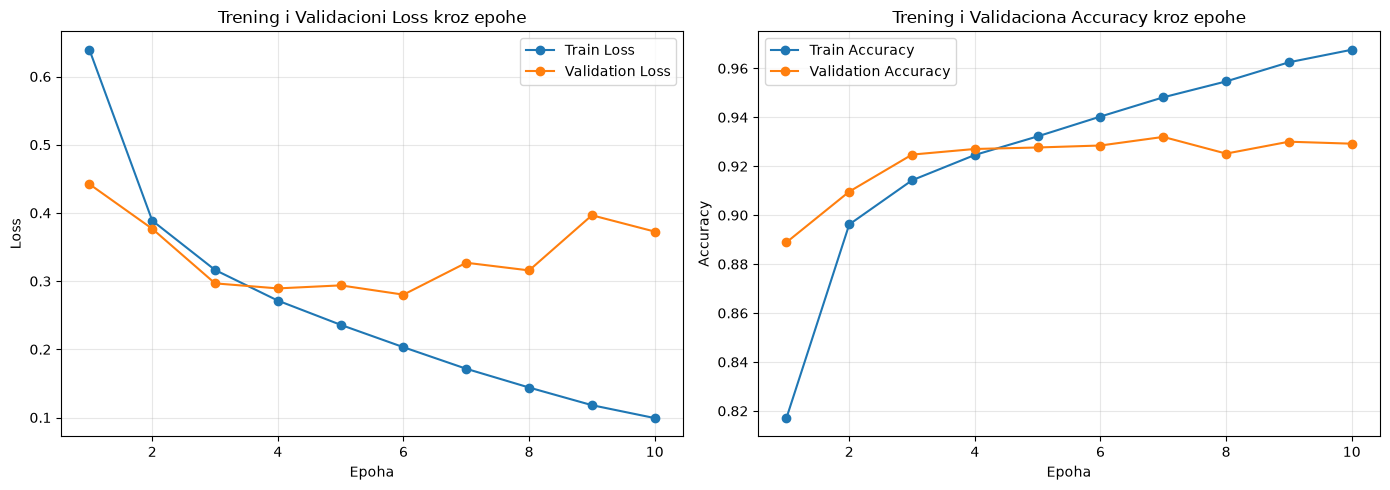

In [5]:
                                                           
                                                                           

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

                    
axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o')
axes[0].plot(epochs_range, val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Trening i Validacioni Loss kroz epohe')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

                         
axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Trening i Validaciona Accuracy kroz epohe')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150)                      
plt.show()

              precision    recall  f1-score   support

         DJI       0.98      0.74      0.84       329
   FutabaT14       0.88      0.81      0.84      1041
    FutabaT7       0.93      0.81      0.86       549
    Graupner       0.98      0.89      0.93       972
       Noise       0.92      0.98      0.95      7883
     Taranis       0.98      0.95      0.97      2482
     Turnigy       0.91      0.83      0.87      1550

    accuracy                           0.93     14806
   macro avg       0.94      0.86      0.90     14806
weighted avg       0.93      0.93      0.93     14806



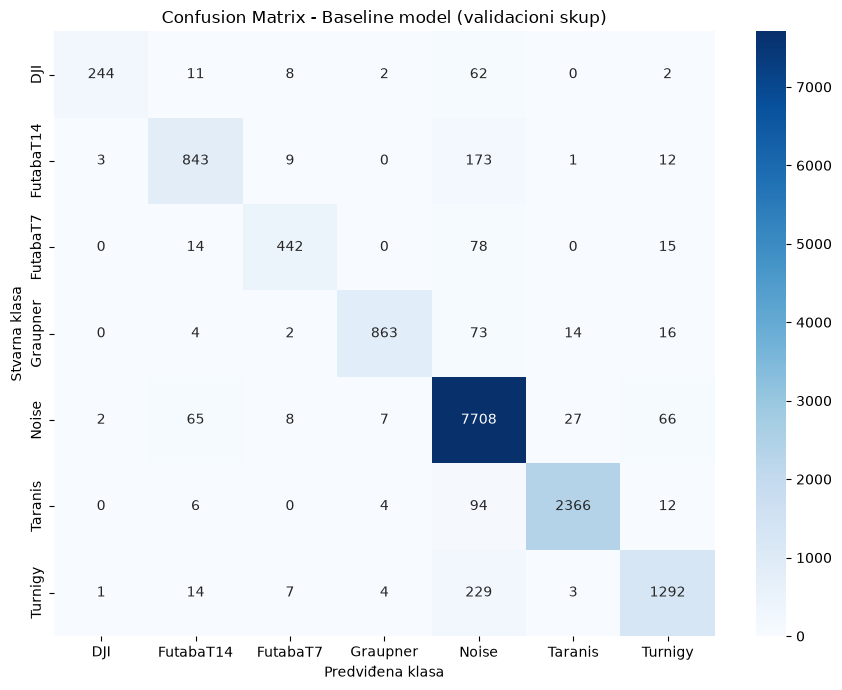

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns                                                    

                                                                              
model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch_specs, batch_labels in val_loader:
        batch_specs = batch_specs.to(device)
        outputs = model(batch_specs)
        _, predicted = torch.max(outputs, dim=1)

                                                                             
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(batch_labels.numpy())

class_names_list = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']

                                                                       
                                                                                 
print(classification_report(all_true_labels, all_predictions, target_names=class_names_list))

                                                                     
cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Confusion Matrix - Baseline model (validacioni skup)')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

Data učitan, val_indices: 14806 uzoraka


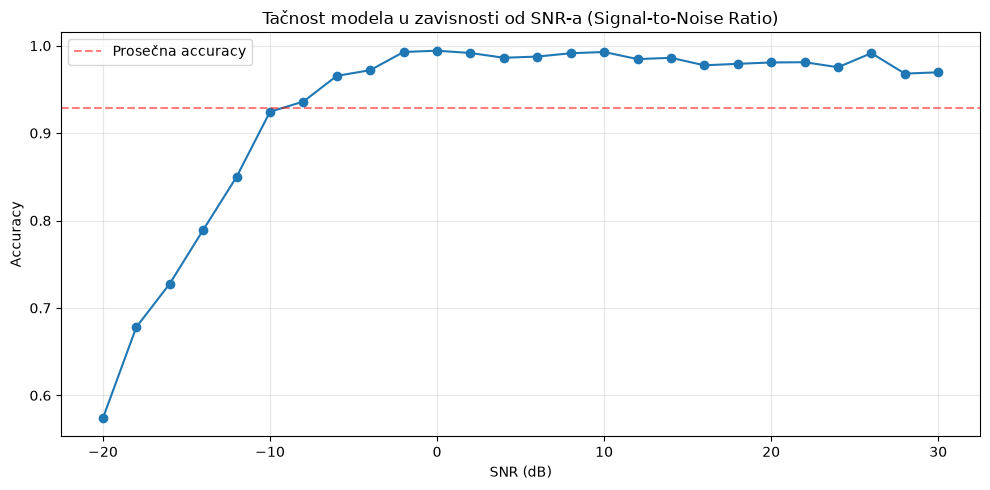

snr
-20    0.573975
-18    0.678082
-16    0.727758
-14    0.789189
-12    0.849906
-10    0.924370
-8     0.936057
-6     0.965451
-4     0.971963
-2     0.992793
 0     0.994231
 2     0.991582
 4     0.986159
 6     0.987522
 8     0.991334
 10    0.992767
 12    0.984615
 14    0.986111
 16    0.977528
 18    0.979239
 20    0.980769
 22    0.981067
 24    0.975329
 26    0.991438
 28    0.968013
 30    0.969534
Name: correct, dtype: float64


In [7]:
import pandas as pd

                                                                         
                                                                   

model.eval()
all_predictions = []
all_true_labels = []
all_snr_values = []

with torch.no_grad():
    for batch_specs, batch_labels in val_loader:
        batch_specs = batch_specs.to(device)
        outputs = model(batch_specs)
        _, predicted = torch.max(outputs, dim=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(batch_labels.numpy())


                                                                     
                                                                                
from drone_dataset import load_data_and_splits

                                                                 
                                                                  
data, train_indices, val_indices, test_indices = load_data_and_splits()

print(f"Data učitan, val_indices: {len(val_indices)} uzoraka")


                                                                               
                                                                                      
val_snr = data['snr'][val_indices].numpy()

                                                            
results_df = pd.DataFrame({
    'true_label': all_true_labels,
    'predicted': all_predictions,
    'snr': val_snr,
    'correct': np.array(all_predictions) == np.array(all_true_labels)
})

                                                                          
accuracy_by_snr = results_df.groupby('snr')['correct'].mean()

                                             
plt.figure(figsize=(10, 5))
plt.plot(accuracy_by_snr.index, accuracy_by_snr.values, marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Tačnost modela u zavisnosti od SNR-a (Signal-to-Noise Ratio)')
plt.grid(True, alpha=0.3)
plt.axhline(y=accuracy_by_snr.mean(), color='r', linestyle='--', alpha=0.5, label='Prosečna accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('baseline_accuracy_by_snr.png', dpi=150)
plt.show()

print(accuracy_by_snr)

In [8]:
                                                                             
                                                                                   
torch.save(model.state_dict(), 'baseline_model.pth')
print("Baseline model sačuvan u 'baseline_model.pth'")

Baseline model sačuvan u 'baseline_model.pth'


In [9]:
from train_utils import train_with_early_stopping

                                              
                                                                              
                                                                             
                                         

torch.manual_seed(SEED)                                                                   

model = BaselineCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)                                       

                                        
history, best_model_state = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=60,
    patience=10
)

                                                          
model.load_state_dict(best_model_state)
model = model.to(device)                                                                                   

print("\nNajbolje težine učitane u model.")

Epoha 1/60 | Train Loss: 0.6384, Train Acc: 0.8177 | Val Loss: 0.4419, Val Acc: 0.8915 <- NOVI NAJBOLJI
Epoha 2/60 | Train Loss: 0.3880, Train Acc: 0.8971 | Val Loss: 0.3550, Val Acc: 0.9120 <- NOVI NAJBOLJI
Epoha 3/60 | Train Loss: 0.3152, Train Acc: 0.9138 | Val Loss: 0.3052, Val Acc: 0.9231 <- NOVI NAJBOLJI
Epoha 4/60 | Train Loss: 0.2720, Train Acc: 0.9243 | Val Loss: 0.2848, Val Acc: 0.9287 <- NOVI NAJBOLJI
Epoha 5/60 | Train Loss: 0.2344, Train Acc: 0.9336 | Val Loss: 0.2801, Val Acc: 0.9316 <- NOVI NAJBOLJI
Epoha 6/60 | Train Loss: 0.2064, Train Acc: 0.9394 | Val Loss: 0.2900, Val Acc: 0.9279 (1/10 bez poboljšanja)
Epoha 7/60 | Train Loss: 0.1734, Train Acc: 0.9467 | Val Loss: 0.3016, Val Acc: 0.9308 (2/10 bez poboljšanja)
Epoha 8/60 | Train Loss: 0.1492, Train Acc: 0.9538 | Val Loss: 0.3207, Val Acc: 0.9281 (3/10 bez poboljšanja)
Epoha 9/60 | Train Loss: 0.1142, Train Acc: 0.9631 | Val Loss: 0.3647, Val Acc: 0.9283 (4/10 bez poboljšanja)
Epoha 10/60 | Train Loss: 0.0960, Train 

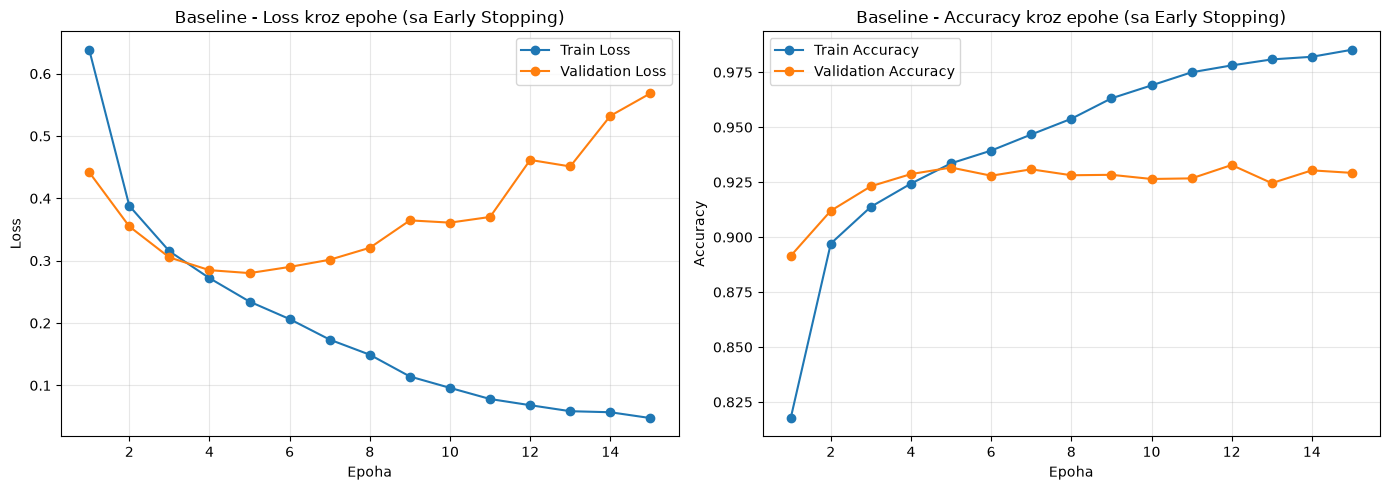

In [10]:
                                                                                    
epochs_completed = len(history['train_loss'])
epochs_range = range(1, epochs_completed + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Baseline - Loss kroz epohe (sa Early Stopping)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Baseline - Accuracy kroz epohe (sa Early Stopping)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150)                        
plt.show()

              precision    recall  f1-score   support

         DJI       0.97      0.69      0.81       329
   FutabaT14       0.96      0.79      0.87      1041
    FutabaT7       0.92      0.76      0.83       549
    Graupner       0.97      0.88      0.93       972
       Noise       0.91      0.99      0.95      7883
     Taranis       0.97      0.96      0.97      2482
     Turnigy       0.94      0.82      0.88      1550

    accuracy                           0.93     14806
   macro avg       0.95      0.84      0.89     14806
weighted avg       0.93      0.93      0.93     14806



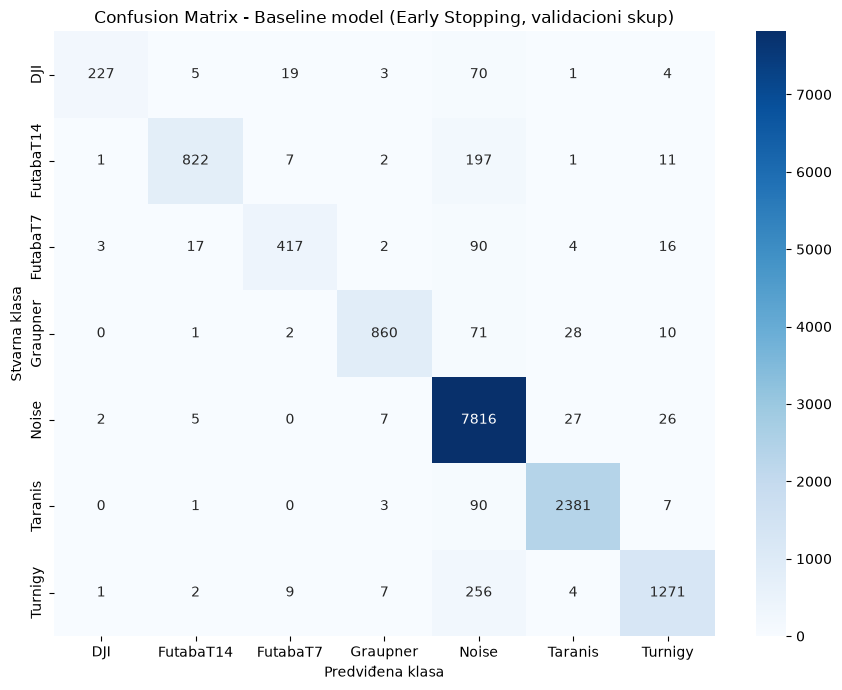

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch_specs, batch_labels in val_loader:
        batch_specs = batch_specs.to(device)
        outputs = model(batch_specs)
        _, predicted = torch.max(outputs, dim=1)
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(batch_labels.numpy())

class_names_list = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']

print(classification_report(all_true_labels, all_predictions, target_names=class_names_list))

cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Confusion Matrix - Baseline model (Early Stopping, validacioni skup)')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)                        
plt.show()

In [12]:
torch.save(model.state_dict(), 'baseline_model.pth')
print("Novi baseline model (sa early stopping) sačuvan.")

Novi baseline model (sa early stopping) sačuvan.
